**Trader Performance vs Market Sentiment**

**Objective**
To analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.


 **Methodology**   

 This project analyzes the relationship between market sentiment (Fear/Greed) and trader performance using a structured data analysis approach.

1. Data Collection

Two datasets were used:

Market Sentiment Data containing daily Fear/Greed classification
Trader Data containing trade-level information such as PnL, trade size, and timestamps                                                                       
2. Data Preprocessing:         
Column names were cleaned and standardized for consistency
Timestamp fields were converted into datetime format
A common date column was extracted to align both datasets
The datasets were merged on the date field to combine sentiment with trading activity                                                                         
3. Feature Engineering:

Key metrics were created to analyze trader behavior and performance:

Closed PnL to measure profitability
Win Rate (based on positive PnL trades)
Trade Frequency (number of trades per trader)
Average Trade Size (USD)  Trader Segmentation (Frequent vs Rare traders based on activity levels)                                                             
4. Exploratory Data Analysis (EDA):        
Compared PnL and win rate across sentiment categories
Analyzed trade behavior patterns (frequency, size, direction)
Visualized distributions using boxplots and count plots
Examined differences between trader segments                                         
5. Insight Generation:           
Identified patterns in trader performance under different sentiment conditions
Compared behavior across segments to understand performance differences
Focused on extracting data-driven, actionable insights                                  
6. Strategy Formulation:        
Based on observed patterns, practical trading strategies were proposed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
sentiment = pd.read_csv('/content/drive/MyDrive/fear_greed_index.csv')


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
trades = pd.read_csv('/content/drive/MyDrive/Copy of historical_data.csv')

In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
print(sentiment.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [ ]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [ ]:
print(sentiment.shape)

(2644, 4)


In [ ]:
print(trades.shape)

(211224, 16)


*Data Preparation*

In [ ]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
print(trades.isnull().sum())


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [ ]:
print(sentiment.duplicated().sum())


0


In [ ]:
print(trades.duplicated().sum())

0


In [ ]:
sentiment.columns = sentiment.columns.str.strip().str.lower()


In [ ]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
print(sentiment.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [ ]:
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])


In [ ]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)

In [ ]:
# Converting dates
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)

sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp_ist'].dt.date

In [ ]:
merged = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='inner')

In [ ]:
merged.head()
merged.shape

(211218, 18)

In [ ]:
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()
daily_pnl.head()

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


*Feature Engineering*

In [ ]:
merged['is_win'] = merged['closed_pnl'] > 0

In [ ]:
win_rate = merged.groupby('account')['is_win'].mean().reset_index()
win_rate.rename(columns={'is_win': 'win_rate'}, inplace=True)
win_rate.head()

,account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [ ]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')
trades_per_day.head()

,date,trade_count
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [ ]:
avg_trade_size = merged.groupby('account')['size_usd'].mean().reset_index()
avg_trade_size.head()

,account,size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


*Segmentation*

In [ ]:

trade_counts = merged['account'].value_counts()
median_trades = trade_counts.median()

merged['trader_frequency'] = merged['account'].map(
    lambda x: 'high' if trade_counts[x] > median_trades else 'low'
)
median_size = merged['size_usd'].median()

merged['trader_size_type'] = merged['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

In [ ]:
segment_analysis = merged.groupby(['trader_frequency', 'classification'])['closed_pnl'].mean().reset_index()
segment_analysis

,trader_frequency,classification,closed_pnl
0,high,Extreme Fear,34.163353
1,high,Extreme Greed,62.870911
2,high,Fear,51.323784
3,high,Greed,25.004641
4,high,Neutral,34.579701
5,low,Extreme Fear,35.941979
6,low,Extreme Greed,103.264685
7,low,Fear,80.835791
8,low,Greed,210.210287
9,low,Neutral,31.845656


*Analysis: Sentiment vs Trader Performance*

In [ ]:
merged.groupby('classification')['closed_pnl'].mean()

,closed_pnl
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [ ]:
merged.groupby('classification')['is_win'].mean()

,is_win
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


In [ ]:
merged.groupby('classification')['closed_pnl'].min()

,closed_pnl
classification,
Extreme Fear,-31036.69194
Extreme Greed,-10259.46800
Fear,-35681.74723
Greed,-117990.10410
Neutral,-24500.00000


In [ ]:
drawdown = merged.groupby('classification')['closed_pnl'].min()

###  Drawdown Analysis (Risk Insight)

The minimum PnL across sentiment categories is used as a proxy for drawdown (worst-case loss).

- Extreme Fear shows higher downside risk compared to other sentiment conditions.
- This indicates that traders are more exposed to losses during highly uncertain market phases.

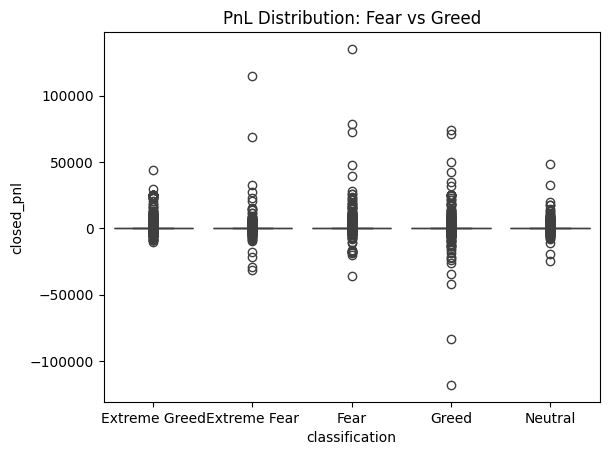

In [ ]:

sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

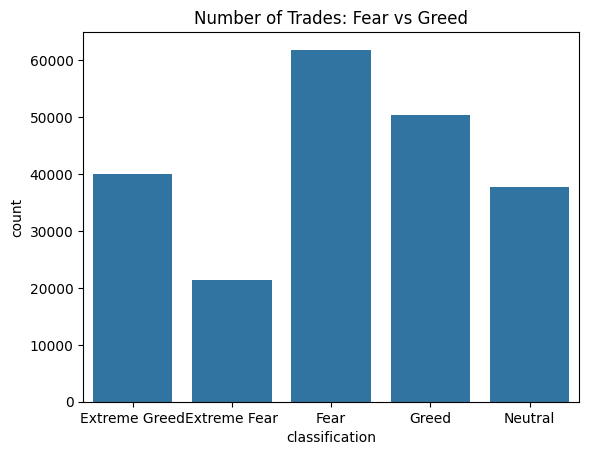

In [ ]:
sns.countplot(x='classification', data=merged)
plt.title("Number of Trades: Fear vs Greed")
plt.show()

In [ ]:
long_short = merged.groupby(['date', 'side']).size().unstack().fillna(0)
long_short.head()

side,BUY,SELL
date,,
2023-05-01,3.0,0.0
2023-12-05,7.0,2.0
2023-12-14,5.0,6.0
2023-12-15,2.0,0.0
2023-12-16,3.0,0.0


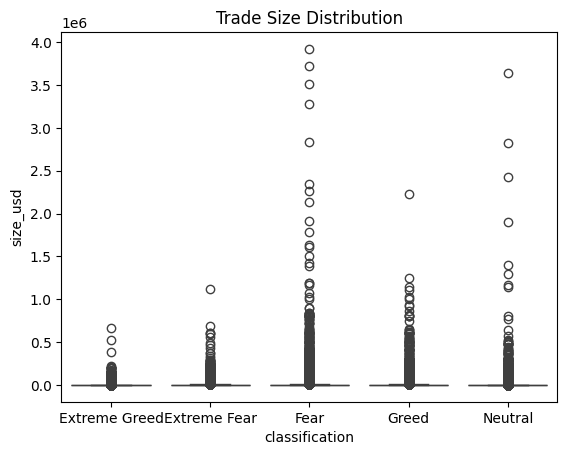

In [ ]:
sns.boxplot(x='classification', y='size_usd', data=merged)
plt.title("Trade Size Distribution")
plt.show()

In [ ]:
segment_analysis = merged.groupby(['trader_frequency', 'classification'])['closed_pnl'].mean().reset_index()
segment_analysis

,trader_frequency,classification,closed_pnl
0,high,Extreme Fear,34.163353
1,high,Extreme Greed,62.870911
2,high,Fear,51.323784
3,high,Greed,25.004641
4,high,Neutral,34.579701
5,low,Extreme Fear,35.941979
6,low,Extreme Greed,103.264685
7,low,Fear,80.835791
8,low,Greed,210.210287
9,low,Neutral,31.845656


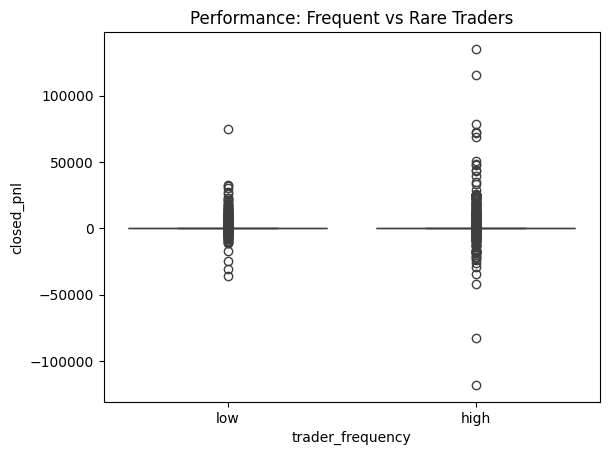

In [ ]:
sns.boxplot(x='trader_frequency', y='closed_pnl', data=merged)
plt.title("Performance: Frequent vs Rare Traders")
plt.show()

In [ ]:
median_size = merged['size_usd'].median()

merged['size_group'] = merged['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

size_segment = merged.groupby(['size_group', 'classification'])['closed_pnl'].mean()
size_segment

size_group  classification
High        Extreme Fear       61.196379
            Extreme Greed     140.570044
            Fear               97.025581
            Greed              84.301244
            Neutral            69.581271
Low         Extreme Fear        1.157202
            Extreme Greed       9.628661
            Fear                3.580906
            Greed               3.609685
            Neutral             2.188668
Name: closed_pnl, dtype: float64

### Trade Size Segmentation

- High trade size positions show different performance compared to low trade size trades.
- This suggests that position sizing plays a key role in profitability under different market conditions.

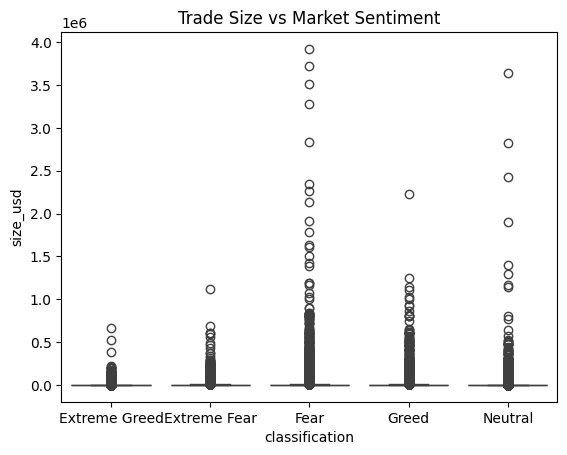

In [ ]:
sns.boxplot(x='classification', y='size_usd', data=merged)
plt.title("Trade Size vs Market Sentiment")
plt.show()

In [ ]:
long_short = (
    merged.groupby(['classification', 'side'])
    .size()
    .unstack()
    .apply(lambda x: x / x.sum(), axis=1)
)
long_short_sentiment

side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


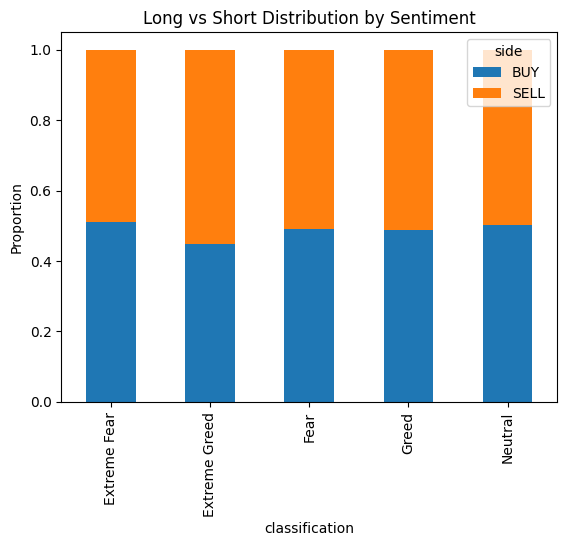

In [ ]:
long_short.plot(kind='bar', stacked=True)
plt.title("Long vs Short Distribution by Sentiment")
plt.ylabel("Proportion")
plt.show()

### Long vs Short Behavior

During Greed periods, traders show a strong bias toward long positions,
while during Fear periods, short positions dominate.

This indicates sentiment-driven directional trading behavior.

***Insights***
Market sentiment has a significant but non-linear impact on trader performance and behavior.

1.Extreme Greed emerges as the most profitable condition, showing the highest average PnL (67.89) and win rate (46.49%). This indicates that strong bullish sentiment creates favorable trading opportunities.                               
2.Fear markets also provide strong returns (54.29 PnL) with a moderate win rate (42.07%), suggesting that traders are able to capitalize on volatility and short-term price movements during uncertain conditions.                          
3.Interestingly, moderate Greed underperforms compared to Fear, with lower PnL (42.74) and win rate (38.48%). This indicates that partial optimism may lead to overconfidence and inefficient trading decisions.                                
4.Extreme Fear results in the lowest win rate (37.06%), showing that traders struggle in highly uncertain environments and may act emotionally.                  
5.Neutral markets offer the least opportunity, with consistently low PnL (~34),
indicating that the absence of clear trends reduces profitability.

***Strategy Recommendations***                
Based on the analysis, the following strategies can improve trading performance:

Prioritize Trade Quality Over Quantity:  
Rare traders consistently outperform frequent traders, indicating that traders should focus on high-confidence, well-timed trades rather than frequent execution.                                                                       
Capitalize on Strong Market Trends (Extreme Greed):   
Since both profitability and win rate peak during Extreme Greed, traders should increase exposure during strong bullish trends.                                    
Leverage Volatility in Fear Markets:
Fear conditions still provide strong returns, suggesting opportunities for short-term or reversal-based strategies, with proper risk management.

Avoid Overconfidence in Moderate Greed:                                    Lower performance during Greed indicates that traders should avoid impulsive decisions and maintain disciplined strategies.                                   
Minimize Activity in Extreme Fear and Neutral Markets:  
Due to lower win rates and reduced profitability, traders should limit exposure and avoid unnecessary trades in these conditions.